# Breast Cancer Diagnosis using Feature-Optimized Logistic Regression
Goal:
Build a highly interpretable breast cancer classifier and reduce the feature
set while maintaining ROC-AUC performance.

Key Question:
How many features are actually needed for near-perfect diagnostic accuracy?

In [1]:
#Importing Necessary Libraries 
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
df.dropna(axis=0)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

## Dataset Overview
- Samples: <print df.shape>
- Target distribution: Malignant vs Benign
- Missing values: Checked and imputed using median strategy

In [2]:
X = df.drop(columns=["diagnosis", "id"])
y = df["diagnosis"].map({"M":1,"B":0})

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

baseline_model = LogisticRegression(max_iter=1000)

baseline_score = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
).mean()

print("Baseline ROC-AUC (no scaling, no feature selection):", baseline_score)


C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

Baseline ROC-AUC (no scaling, no feature selection): 0.9926134108700436


C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Why the Baseline Score is Misleading

The baseline Logistic Regression model achieved a high ROC-AUC score. However, training produced convergence warnings due to unscaled features and heterogeneous feature magnitudes. This indicates that the optimizer failed to fully converge, making the baseline performance numerically unstable and unreliable. Furthermore, the baseline approach does not include imputation, feature sel

## Why a Pipeline?

Logistic Regression is sensitive to scale.  
Breast cancer features have large magnitude differences.
Therefore we combine:

Imputer → StandardScaler → SelectKBest → LogisticRegression

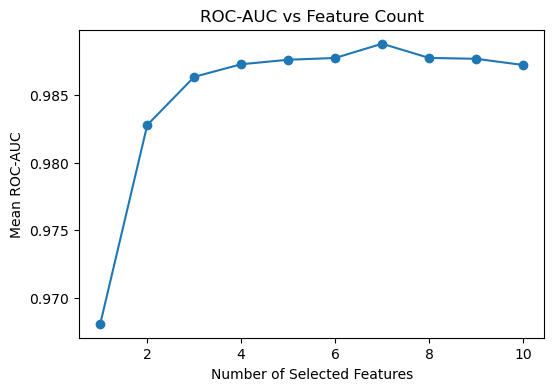

In [4]:
k_values = range(1, 11)
scores = []

for k in k_values:
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(f_classif, k=k)),
        ("model", LogisticRegression(max_iter=1000))
    ])

    roc_auc = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc").mean()
    scores.append(roc_auc)

plt.figure(figsize=(6,4))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean ROC-AUC")
plt.title("ROC-AUC vs Feature Count")
plt.show()

## Feature Dominance

We observe that just two features:
- concave_points_worst
- perimeter_worst

achieve ROC-AUC > 0.98, proving strong morphological dominance in diagnosis.


In [5]:
#Pipeline
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(f_classif, k=3)),
    ("model", LogisticRegression(max_iter=1000))
])

In [6]:
#Cross Validation
scores = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
print("Mean ROC-AUC:", scores.mean())

Mean ROC-AUC: 0.9863409786886695


In [7]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('selector', SelectKBest(k=3)),
                ('model', LogisticRegression(max_iter=1000))])

In [8]:
#Save Model
bundle = {
    "model": pipe,
    "features": X.columns.tolist()
}

joblib.dump(bundle, "breast_cancer_pipeline.pkl")

['breast_cancer_pipeline.pkl']

In [9]:
#Feature Extraction
selector = pipe.named_steps["selector"]
mask = selector.get_support()

selected_features = X_train.columns[mask]

print("\nSelected Features:")
for f in selected_features:
    print(f)


Selected Features:
radius_worst
perimeter_worst
concave points_worst


In [10]:
#Feature Importance 
coef = pipe.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": selected_features,
    "weight": coef,
    "abs_weight": np.abs(coef)
}).sort_values("abs_weight", ascending=False)

print("\nFeature Importance:")
print(importance)


Feature Importance:
                feature    weight  abs_weight
2  concave points_worst  2.186573    2.186573
0          radius_worst  2.137522    2.137522
1       perimeter_worst  1.603668    1.603668


This project demonstrates that careful preprocessing and feature selection can achieve near-optimal
performance using extremely simple linear models, emphasizing the importance of data understanding
over model complexity in classical machine learning problems.